# İstanbul Topkapı Üniversitesi
## Derin Öğrenme Final Ödevi
### YOLOv8 Tabanlı Derin Öğrenme Yaklaşımlarıyla Beyin Tümörü Tespiti

---

**Veri Seti:** Ultralytics Brain Tumor Detection  
**Model:** YOLOv8n (Transfer Öğrenme)  
**Sınıflar:** 0 - Negatif, 1 - Pozitif

## 1. Kütüphane Kurulumu

In [1]:
!pip install ultralytics -q

import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
print('Kutuphaneler yuklendi!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Kutuphaneler yuklendi!


## 2. Veri Seti İndirme

In [2]:
!mkdir -p /content/datasets
!cd /content/datasets && wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip && unzip -q -o brain-tumor.zip && rm brain-tumor.zip
!echo '=== Klasor Yapisi ===' && find /content/datasets/ -type d | head -20

=== Klasor Yapisi ===
/content/datasets/
/content/datasets/images
/content/datasets/images/val
/content/datasets/images/train
/content/datasets/labels
/content/datasets/labels/val
/content/datasets/labels/train


In [3]:
import subprocess
result = subprocess.run(['find', '/content/datasets', '-name', '*.jpg', '-o', '-name', '*.png'], capture_output=True, text=True)
all_imgs = [p for p in result.stdout.strip().split('\n') if p]
print(f'Toplam goruntu: {len(all_imgs)}')

train_images = sorted([p for p in all_imgs if '/train/' in p])
val_images = sorted([p for p in all_imgs if '/val/' in p or '/valid/' in p])

train_img_dir = os.path.dirname(train_images[0])
val_img_dir = os.path.dirname(val_images[0])
train_lbl_dir = train_img_dir.replace('images', 'labels')
val_lbl_dir = val_img_dir.replace('images', 'labels')

dataset_root = train_img_dir
for _ in range(3):
    parent = os.path.dirname(dataset_root)
    if os.path.basename(parent) == 'datasets' or parent == dataset_root:
        break
    dataset_root = parent

yaml_train = os.path.relpath(train_img_dir, dataset_root)
yaml_val = os.path.relpath(val_img_dir, dataset_root)

print(f'Egitim: {len(train_images)} | Dogrulama: {len(val_images)}')
print(f'Root: {dataset_root}')
print(f'Train: {yaml_train} | Val: {yaml_val}')

Toplam goruntu: 1116
Egitim: 893 | Dogrulama: 223
Root: /content/datasets/images
Train: train | Val: val


## 3. YAML Dosyası Hazırlama

In [4]:
yaml_content = f"""path: {dataset_root}
train: {yaml_train}
val: {yaml_val}

names:
  0: negative
  1: positive
"""

yaml_path = '/content/brain-tumor.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print('YAML dosyasi:')
print(yaml_content)

t = os.path.join(dataset_root, yaml_train)
v = os.path.join(dataset_root, yaml_val)
print(f'Train var mi: {os.path.exists(t)} ({len(os.listdir(t))} dosya)')
print(f'Val var mi  : {os.path.exists(v)} ({len(os.listdir(v))} dosya)')

YAML dosyasi:
path: /content/datasets/images
train: train
val: val

names:
  0: negative
  1: positive

Train var mi: True (893 dosya)
Val var mi  : True (223 dosya)


## 4. Örnek MR Görüntüleri

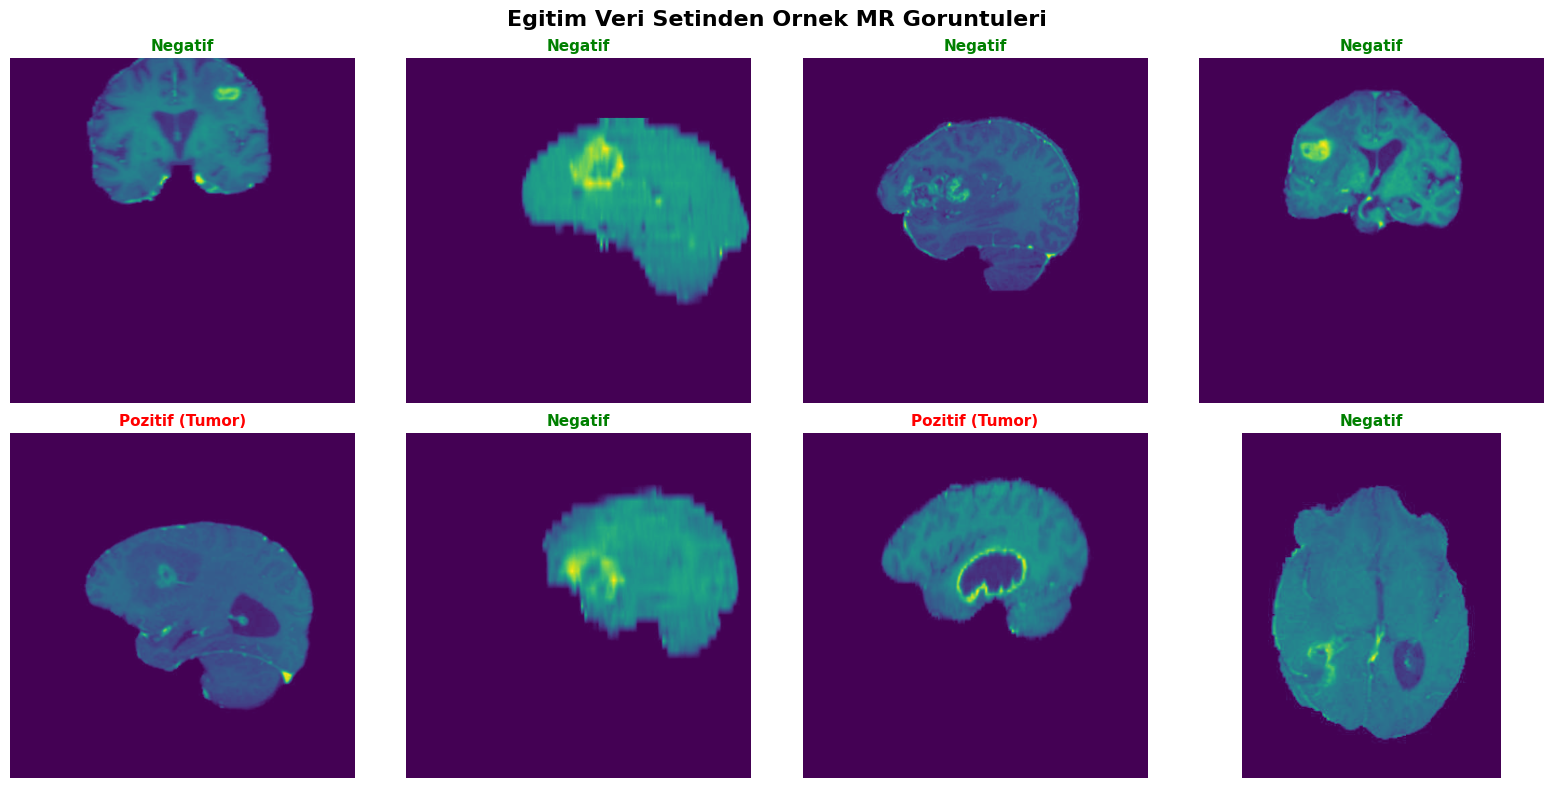

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Egitim Veri Setinden Ornek MR Goruntuleri', fontsize=16, fontweight='bold')

samples = random.sample(train_images, min(8, len(train_images)))

for idx, img_path in enumerate(samples):
    row, col = idx // 4, idx % 4
    img = mpimg.imread(img_path)
    axes[row, col].imshow(img)

    img_name = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, img_name + '.txt')

    label = 'Bilinmiyor'
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            content = f.read().strip()
            if content:
                cls = int(content.split()[0])
                label = 'Pozitif (Tumor)' if cls == 1 else 'Negatif'
            else:
                label = 'Negatif (bos)'

    color = 'red' if 'Pozitif' in label else 'green'
    axes[row, col].set_title(label, fontsize=11, color=color, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 5. Sınıf Dağılımı Analizi

Egitim   -> Negatif: 437, Pozitif: 488
Dogrulama -> Negatif: 154, Pozitif: 87


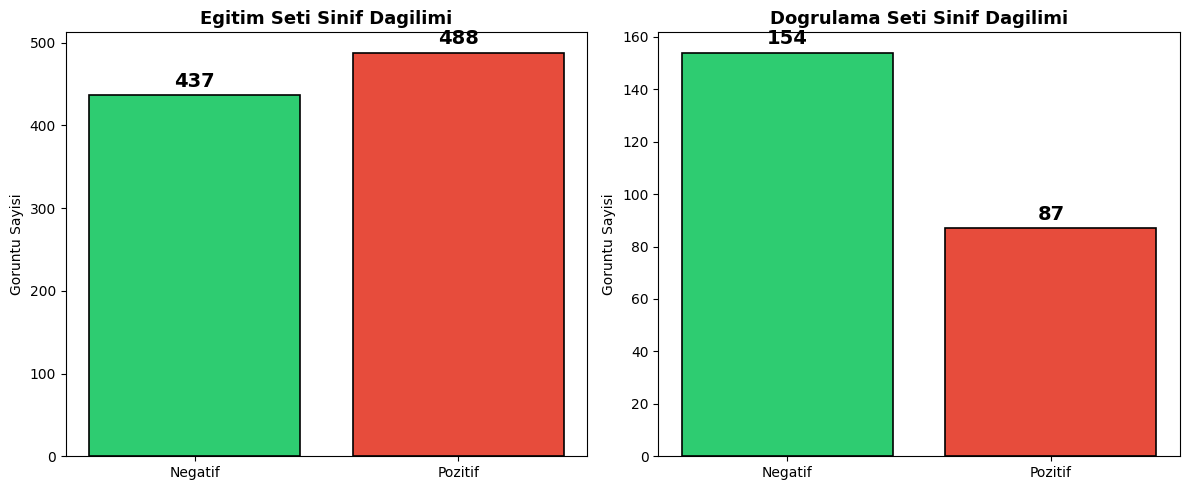

In [6]:
def count_classes(label_dir):
    neg, pos, empty = 0, 0, 0
    for lbl in glob.glob(os.path.join(label_dir, '*.txt')):
        with open(lbl, 'r') as f:
            content = f.read().strip()
            if not content:
                empty += 1
                continue
            for line in content.split('\n'):
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    if cls == 0: neg += 1
                    else: pos += 1
    return neg, pos, empty

train_neg, train_pos, _ = count_classes(train_lbl_dir)
val_neg, val_pos, _ = count_classes(val_lbl_dir)

print(f'Egitim   -> Negatif: {train_neg}, Pozitif: {train_pos}')
print(f'Dogrulama -> Negatif: {val_neg}, Pozitif: {val_pos}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']

for ax, data, title in [(axes[0], [train_neg, train_pos], 'Egitim Seti'),
                         (axes[1], [val_neg, val_pos], 'Dogrulama Seti')]:
    bars = ax.bar(['Negatif', 'Pozitif'], data, color=colors, edgecolor='black', linewidth=1.2)
    ax.set_title(f'{title} Sinif Dagilimi', fontsize=13, fontweight='bold')
    ax.set_ylabel('Goruntu Sayisi')
    for bar, v in zip(bars, data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(data)*0.02,
                str(v), ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 6. Veri Artırma (Data Augmentation) Stratejileri

YOLOv8, eğitim sırasında otomatik olarak çeşitli veri artırma teknikleri uygular.
Bu teknikler modelin genelleme kapasitesini artırarak overfitting'i önler:

| Teknik | Açıklama |
|---|---|
| **Mozaik (Mosaic)** | 4 farklı görüntüyü birleştirerek çeşitlilik artırır |
| **Ölçekleme (Scale)** | Görüntü boyutunu ±%50 rastgele değiştirir |
| **Yatay Çevirme (Flip)** | %50 olasılıkla yatay eksende çevirir |
| **HSV Augmentation** | Renk tonu, doygunluk ve parlaklık değişiklikleri |
| **Döndürme (Rotation)** | Rastgele açılarla döndürme uygular |
| **Kırpma (Crop)** | Rastgele bölgeleri kırparak farklı bakış açıları sunar |

Bu teknikler sayesinde 893 eğitim görüntüsü, eğitim sırasında binlerce farklı varyasyona dönüştürülür.

## 7. YOLOv8n Model Eğitimi (Transfer Öğrenme)

- **Model:** YOLOv8n (Nano, 3.2M parametre)
- **Transfer Öğrenme:** COCO veri seti üzerinde eğitilmiş ağırlıklar başlangıç noktası
- **Epoch:** 50 | **Görüntü:** 640x640 | **Batch:** 16
- **Early Stopping:** 10 epoch boyunca iyileşme olmazsa durur

In [7]:
model = YOLO('yolov8n.pt')

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name='brain_tumor_yolov8n',
    project='/content/runs/detect',
    exist_ok=True,
    patience=10,
    save=True,
    plots=True,
    verbose=True
)

print('\nEgitim tamamlandi!')

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

## 8. Model Değerlendirme

In [8]:
best_path = '/content/runs/detect/brain_tumor_yolov8n/weights/best.pt'
if not os.path.exists(best_path):
    candidates = sorted(glob.glob('/content/runs/detect/brain_tumor_yolov8n*/weights/best.pt'))
    best_path = candidates[-1] if candidates else best_path

print(f'Model: {best_path}')
best_model = YOLO(best_path)
metrics = best_model.val(data=yaml_path, imgsz=640, plots=True)

print('\n' + '=' * 50)
print('  DEGERLENDIRME SONUCLARI')
print('=' * 50)
print(f'  Precision : {metrics.box.mp:.4f}')
print(f'  Recall    : {metrics.box.mr:.4f}')
print(f'  mAP@0.5   : {metrics.box.map50:.4f}')
print(f'  mAP@0.5:95: {metrics.box.map:.4f}')
print('=' * 50)

Model: /content/runs/detect/brain_tumor_yolov8n/weights/best.pt
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 209.6±107.5 MB/s, size: 3.1 KB)
val: Scanning /content/datasets/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 103.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.2it/s 3.4s
                   all        223        241      0.452      0.804       0.49      0.352
              negative        142        154      0.568      0.803      0.599      0.433
              positive         81         87      0.336      0.805      0.382       0.27
Speed: 2.8ms preprocess, 4.6ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val

  DEGERLENDIRME SONUCLARI
  Precision : 

## 9. Eğitim Grafikleri ve Karışıklık Matrisi

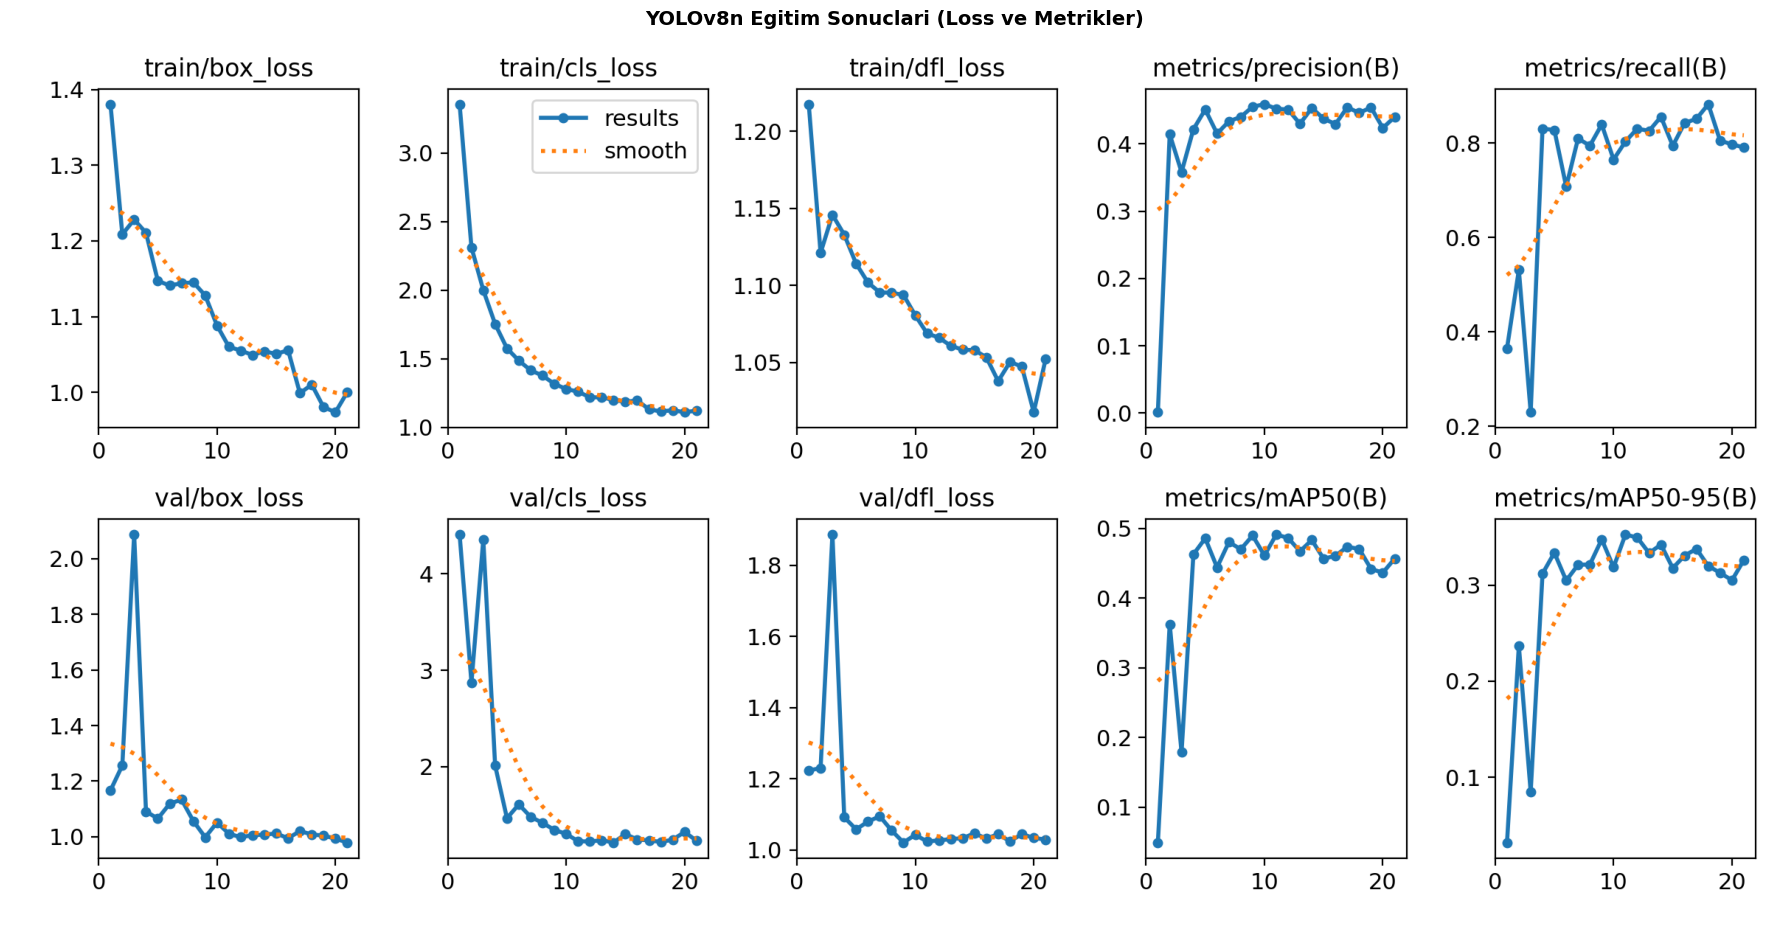

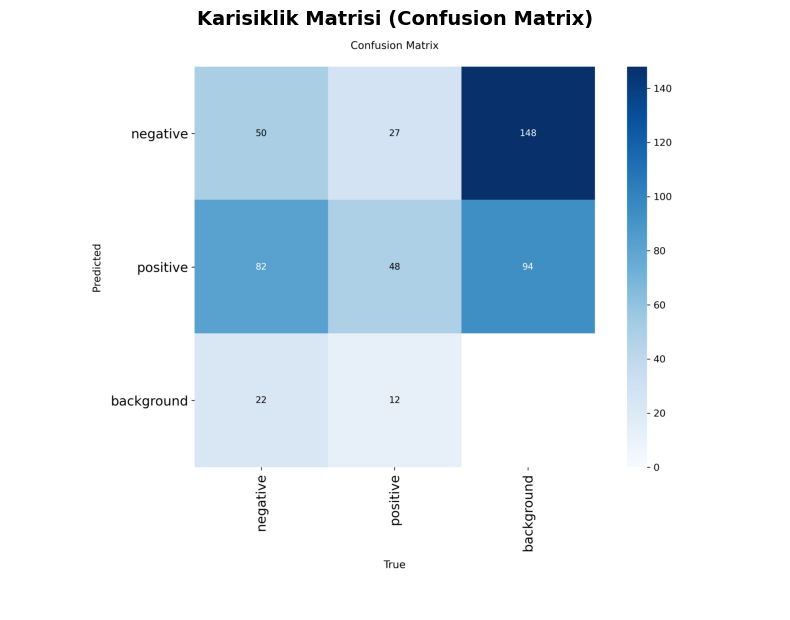

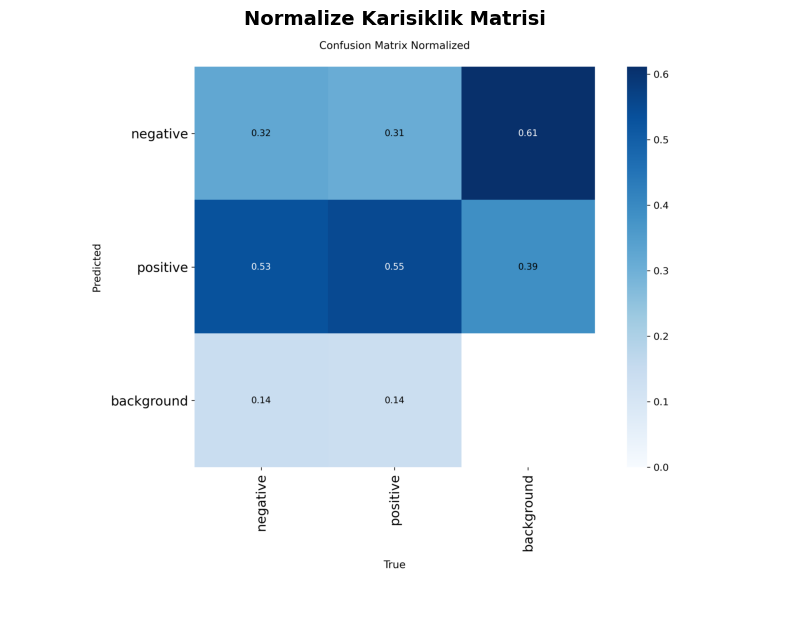

In [9]:
run_dir = os.path.dirname(os.path.dirname(best_path))

plot_files = [
    ('results.png', 'YOLOv8n Egitim Sonuclari (Loss ve Metrikler)', (18, 10)),
    ('confusion_matrix.png', 'Karisiklik Matrisi (Confusion Matrix)', (8, 8)),
    ('confusion_matrix_normalized.png', 'Normalize Karisiklik Matrisi', (8, 8)),
]

for fname, title, figsize in plot_files:
    fpath = os.path.join(run_dir, fname)
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 10. Modelin Güvenilirliği Analizi

Modelin güvenilirliği farklı eğriler ile analiz edilir:

- **F1-Confidence:** Farklı güven eşiklerinde F1 skorunu gösterir. Optimum eşik, F1'in en yüksek olduğu noktadır.
- **Precision-Recall:** Kesinlik ve duyarlılık arasındaki dengeyi gösterir. Eğri altı alan büyükse model başarılıdır.
- **Precision-Confidence:** Güven eşiği arttıkça kesinliğin değişimini gösterir.
- **Recall-Confidence:** Güven eşiği arttıkça duyarlılığın değişimini gösterir.

> **Tıbbi Not:** Beyin tümörü tespitinde **yüksek Recall** kritik öneme sahiptir. Bir tümörü kaçırmak (yanlış negatif), yanlış alarm vermekten (yanlış pozitif) çok daha tehlikelidir.

In [10]:
# Guvenilirlik analizi grafikleri
confidence_plots = [
    ('F1_curve.png', 'F1-Confidence Egrisi'),
    ('PR_curve.png', 'Precision-Recall Egrisi'),
    ('P_curve.png', 'Precision-Confidence Egrisi'),
    ('R_curve.png', 'Recall-Confidence Egrisi'),
]

for fname, title in confidence_plots:
    fpath = os.path.join(run_dir, fname)
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## 11. Örnek Tahminler (Inference)


0: 640x640 1 negative, 6.6ms
1: 640x640 (no detections), 6.6ms
2: 640x640 1 negative, 1 positive, 6.6ms
3: 640x640 1 negative, 6.6ms
4: 640x640 1 positive, 6.6ms
5: 640x640 2 negatives, 6.6ms
Speed: 2.3ms preprocess, 6.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predictions


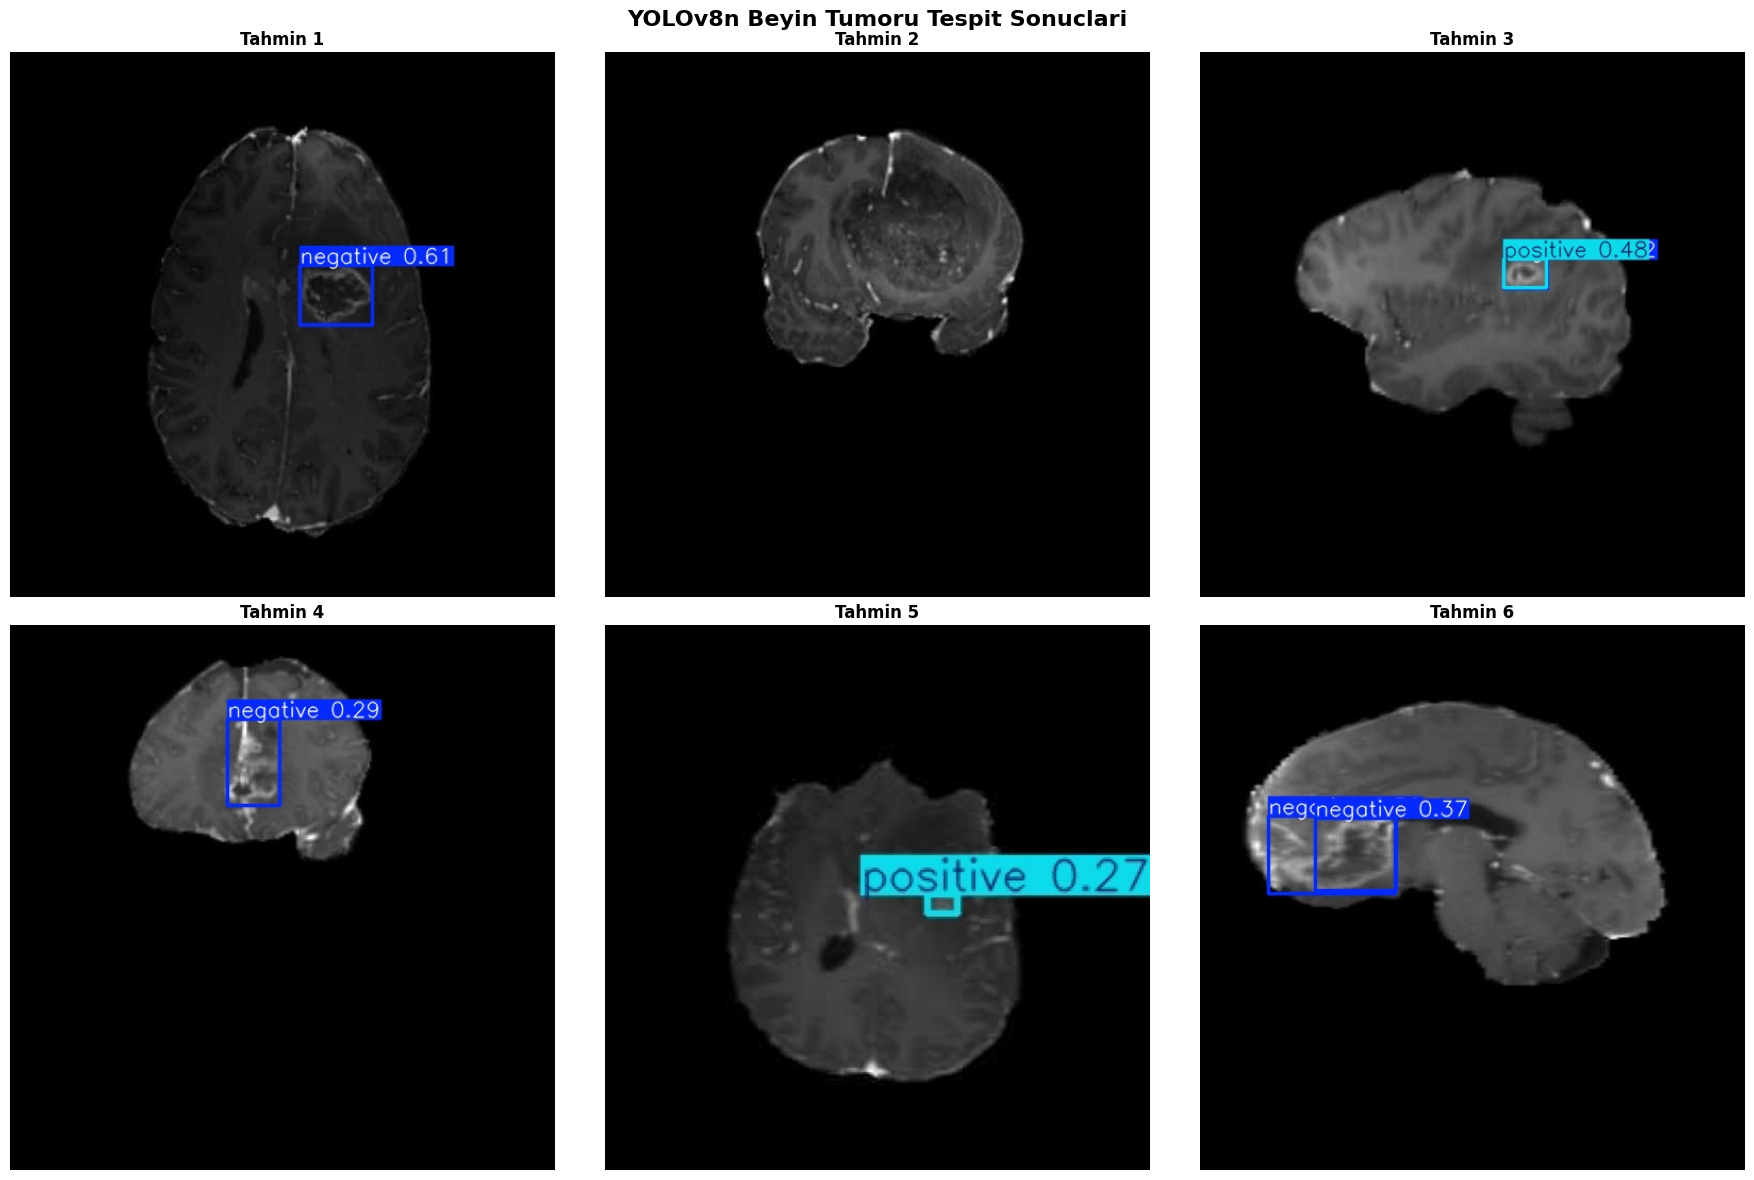

In [11]:
samples_val = random.sample(val_images, min(6, len(val_images)))
best_model.predict(
    source=samples_val, imgsz=640, conf=0.25, save=True,
    project='/content/runs/detect', name='predictions', exist_ok=True
)

pred_dir = '/content/runs/detect/predictions'
pred_imgs = sorted(glob.glob(os.path.join(pred_dir, '*.jpg')) + glob.glob(os.path.join(pred_dir, '*.png')))

n = min(6, len(pred_imgs))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('YOLOv8n Beyin Tumoru Tespit Sonuclari', fontsize=16, fontweight='bold')

for idx in range(6):
    r, c = idx // 3, idx % 3
    if idx < n:
        axes[r, c].imshow(mpimg.imread(pred_imgs[idx]))
        axes[r, c].set_title(f'Tahmin {idx+1}', fontsize=12, fontweight='bold')
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

## 12. Sonuç Özeti

In [12]:
print('=' * 55)
print('  PROJE SONUC OZETI')
print('=' * 55)
print(f'  Model : YOLOv8n (Transfer Ogrenme - yolov8n.pt)')
print(f'  Veri  : {len(train_images)} egitim + {len(val_images)} dogrulama')
print(f'  Sinif : 0-Negatif, 1-Pozitif')
print(f'  Epoch : 50 | Boyut: 640 | Batch: 16')
print(f'')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')
print(f'  mAP@0.5    : {metrics.box.map50:.4f}')
print(f'  mAP@0.5:95 : {metrics.box.map:.4f}')
print('=' * 55)
print('Proje basariyla tamamlandi!')

  PROJE SONUC OZETI
  Model : YOLOv8n (Transfer Ogrenme - yolov8n.pt)
  Veri  : 893 egitim + 223 dogrulama
  Sinif : 0-Negatif, 1-Pozitif
  Epoch : 50 | Boyut: 640 | Batch: 16

  Precision  : 0.4523
  Recall     : 0.8039
  mAP@0.5    : 0.4901
  mAP@0.5:95 : 0.3519
Proje basariyla tamamlandi!
